In [ ]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(67)

In [2]:
integrated_function = lambda x: 4/(1+x**2)


In [3]:
def generate_nodes(start,end,m):
    number_of_nodes = 2**m +1
    return np.linspace(start,end,number_of_nodes)

In [4]:
def midpoint_rule(f, a, b, m):
    n = 2**m+1
    dx = (b - a) / n
    x_mid = np.linspace(a + dx/2, b - dx/2, n)
    return np.sum(f(x_mid)) * dx

In [5]:
START = 0
END = 1
results_trapezoid = []
results_simpson = []
results_midpoint = []
for m in range(1,26):
    x_s = generate_nodes(START,END,m)
    y_s = integrated_function(x_s)
    results_trapezoid.append(scipy.integrate.trapezoid(y_s,x_s))
    results_simpson.append(scipy.integrate.simpson(y_s,x_s))
    results_midpoint.append(midpoint_rule(integrated_function,START,END,m))


In [6]:

results_midpoint = np.array(results_midpoint)
results_simpson = np.array(results_simpson)
results_trapezoid = np.array(results_trapezoid)

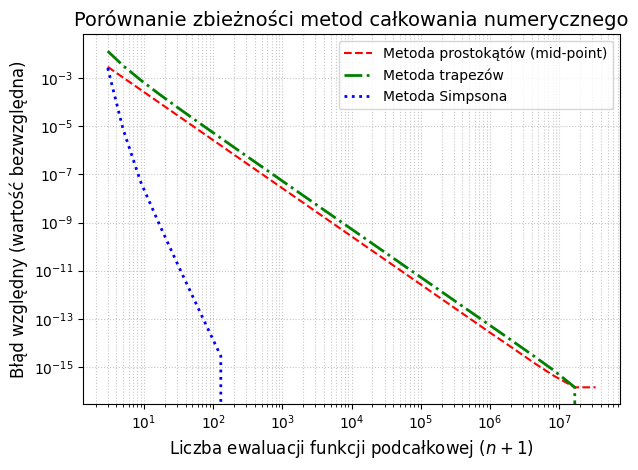

In [7]:
n_s = [2**m+1 for m in range(1,26)]
midpoint_error = np.abs(results_midpoint-np.pi)/np.pi
trapezoid_error = np.abs(results_trapezoid-np.pi)/np.pi
simpson_error = np.abs(results_simpson-np.pi)/np.pi


plt.loglog(n_s, midpoint_error, 'r--', linewidth=1.5, label='Metoda prostokątów (mid-point)')
plt.loglog(n_s, trapezoid_error, 'g-.', linewidth=2, label='Metoda trapezów')
plt.loglog(n_s, simpson_error, 'b:', linewidth=2, label='Metoda Simpsona')
plt.title('Porównanie zbieżności metod całkowania numerycznego', fontsize=14)
plt.xlabel('Liczba ewaluacji funkcji podcałkowej ($n+1$)', fontsize=12)
plt.ylabel('Błąd względny (wartość bezwzględna)', fontsize=12)

plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which="both", linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [8]:
print(midpoint_error,"\n\n")
print(trapezoid_error,"\n\n")
print(simpson_error,"\n\n")

[2.94645337e-03 1.06099383e-03 3.27478156e-04 9.17848323e-05
 2.43579645e-05 6.27830149e-06 1.59400420e-06 4.01608258e-07
 1.00793877e-07 2.52476611e-08 6.31807787e-09 1.58029068e-09
 3.95169077e-10 9.88042846e-11 2.47025907e-11 6.17578904e-12
 1.54405328e-12 3.86048659e-13 9.66888623e-14 2.41722156e-14
 6.21975138e-15 1.55493784e-15 4.24073958e-16 1.41357986e-16
 1.41357986e-16] 


[1.32393528e-02 3.31557403e-03 8.28929586e-04 2.07232961e-04
 5.18082491e-05 1.29520624e-05 3.23801561e-06 8.09503902e-07
 2.02375975e-07 5.05939938e-08 1.26484984e-08 3.16212443e-09
 7.90531248e-10 1.97632741e-10 4.94082914e-11 1.23518608e-11
 3.08796520e-12 7.72097319e-13 1.92953651e-13 4.82030732e-14
 1.20154288e-14 2.96851770e-15 7.06789929e-16 1.41357986e-16
 0.00000000e+00] 


[2.62902329e-03 7.64775751e-06 4.81065190e-08 7.52793755e-10
 1.17638116e-11 1.83765382e-13 2.82715972e-15 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00

In [9]:
H_MIN_CALCULATED = 9.123695225180451e-09

min_idx_s = np.array([np.argmin(array) for array in [midpoint_error,trapezoid_error,simpson_error]])
m_min = min_idx_s + 1 # Ponieważ pętla zaczyna się od m=1
n_min = 2**m_min
h_min = 1 / n_min
for m,h in zip(m_min,h_min):
    print(f"Błąd metody trapezów przestaje maleć dla m = {m}")
    print(f"Odpowiada to krokowi h_min = {h}")
    print()

Błąd metody trapezów przestaje maleć dla m = 24
Odpowiada to krokowi h_min = 5.960464477539063e-08

Błąd metody trapezów przestaje maleć dla m = 25
Odpowiada to krokowi h_min = 2.9802322387695312e-08

Błąd metody trapezów przestaje maleć dla m = 8
Odpowiada to krokowi h_min = 0.00390625



In [10]:
def calculate_empirical_rank(errors):
    # Wybieramy pierwsze 5 kroków, gdzie błąd metody wyraźnie przeważa nad numerycznym
    # Dzielimy błąd z kroku m przez błąd z kroku m+1
    rzędy = np.log2(errors[0:5] / errors[1:6])
    return np.mean(rzędy)

print("--- Porównanie rzędów zbieżności ---")
print(f"Prostokąty: empiryczny = {calculate_empirical_rank(midpoint_error):.2f}, teoretyczny = 2.0")
print(f"Trapezy:    empiryczny = {calculate_empirical_rank(trapezoid_error):.2f}, teoretyczny = 2.0")
print(f"Simpson:    empiryczny = {calculate_empirical_rank(simpson_error):.2f}, teoretyczny = 4.0")

--- Porównanie rzędów zbieżności ---
Prostokąty: empiryczny = 1.77, teoretyczny = 2.0
Trapezy:    empiryczny = 2.00, teoretyczny = 2.0
Simpson:    empiryczny = 6.75, teoretyczny = 4.0
